In [2]:
# in this script want extract neural data from the HDF5 files
# Dataset for W. E. Allen, et al., "Thirst regulates motivated behavior through modulation of brainwide neural population dynamics", Science (2019)
# Data stacture:
'''
Each HDF5 file includes histological information, firing rate information, and behavioral information, as well as some basic information about each unit.

Histological:
areas (Nunit): area encodings using final collapsed hierarchy (area names listed in area_map.csv)
areas_aibs (Nunit): area encoding from Allen Brain Institute (AIBS) atlas.
areas_aibs_higher (Nunit): area encoding from Allen Brain Institute (AIBS) atlas at high-level cut of hierarchy.
depth (Nunit): depth of each unit along probe
locs (Nunit x 3): registered 3D location of each unit within the AIBS reference space.
Behavioral:
session (Ntrial): which session each trial come from (session 0 = endogenous thirst, session 1 = optogenetic stimulation, session 2 = washout)
behavior (5 x 600 x Ntrial): matrix of binary-encoded behavioral data, binned at 10 ms time resolution. 
Row 1: Go odor timing
Row 2: No-Go odor timing
Row 3: Reward time
Row 4: Lick times
Row 5: Stim times 
Activity:
rates (Nunit x 600 x Ntrial): firing rates for each unit binned at 10 ms time resolution (6 s per trial), by number of trials.
Diagnostic:
fp_rate (Nunit): estimated false positive rate (note: may be inaccurate)
avg_fr (Nunit): average firing rate of each neuron across session.'''

'\nEach HDF5 file includes histological information, firing rate information, and behavioral information, as well as some basic information about each unit.\n\nHistological:\nareas (Nunit): area encodings using final collapsed hierarchy (area names listed in area_map.csv)\nareas_aibs (Nunit): area encoding from Allen Brain Institute (AIBS) atlas.\nareas_aibs_higher (Nunit): area encoding from Allen Brain Institute (AIBS) atlas at high-level cut of hierarchy.\ndepth (Nunit): depth of each unit along probe\nlocs (Nunit x 3): registered 3D location of each unit within the AIBS reference space.\nBehavioral:\nsession (Ntrial): which session each trial come from (session 0 = endogenous thirst, session 1 = optogenetic stimulation, session 2 = washout)\nbehavior (5 x 600 x Ntrial): matrix of binary-encoded behavioral data, binned at 10 ms time resolution. \nRow 1: Go odor timing\nRow 2: No-Go odor timing\nRow 3: Reward time\nRow 4: Lick times\nRow 5: Stim times \nActivity:\nrates (Nunit x 600 

In [3]:
import h5py
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import requests


In [4]:
# helper function to get AIBS area name from structure ID 


# read online -> this is sp slow 

def get_aibs_name(struct_id):
    url = f"http://api.brain-map.org/api/v2/data/Structure/{struct_id}.json"
    r = requests.get(url).json()
    return r['msg'][0]['name']

# Download AIBS ontology CSV from Allen Brain API
ONTOLOGY_URL_JSON = "http://api.brain-map.org/api/v2/structure_graph_download/1.json"

def _traverse_structures(node, id_to_name, id_to_acronym=None):
    """Recursively collect id → name (and optionally acronym) from a nested AIBS structure node."""
    sid = int(node["id"])
    id_to_name[sid] = node["name"]
    if id_to_acronym is not None:
        id_to_acronym[sid] = node.get("acronym", "")

    for child in node.get("children", []):
        _traverse_structures(child, id_to_name, id_to_acronym)


def load_aibs_id_to_name(url: str = ONTOLOGY_URL_JSON, return_acronym: bool = False):
    """
    Download Allen Brain Institute ontology JSON and return:
      - id_to_name dict
      - (optionally) id_to_acronym dict
    """
    print(f"Downloading ontology from:\n  {url}")
    r = requests.get(url)
    r.raise_for_status()
    data = r.json()

    id_to_name = {}
    id_to_acronym = {} if return_acronym else None

    # data["msg"] is usually a list of root structures (often length 1)
    for root in data["msg"]:
        _traverse_structures(root, id_to_name, id_to_acronym)

    print(f"Collected {len(id_to_name)} structures from ontology.")
    if return_acronym:
        return id_to_name, id_to_acronym
    else:
        return id_to_name


def map_areas_to_names(areas_aibs: np.ndarray, id_to_name: dict) -> np.ndarray:
    """
    Map an array of AIBS area IDs (areas_aibs) to names.
    If an ID is missing, return 'UNKNOWN_<id>'.
    """
    names = []
    for a in areas_aibs:
        key = int(a)
        names.append(id_to_name.get(key, f"UNKNOWN_{key}"))
    return np.array(names, dtype=object)

In [5]:
# Thirsty and sated blocks were determined using a Hidden Markov Model of the total number of licks per Go trial, smoothed with a 10 trial moving average filter.
# let fidn the Thirsty and sated blocks (there is one thirsty block falling one sated block in session 0) using Hidden Markov Model
from hmmlearn import hmm
def identify_thirsty_sated_blocks(behavior_df, lick_column='num_licks', go_nogo_column='go_or_nogo', smoothed_window=10, selected_session = 0, seed = 42):
    # Filter to only Go trials in the selected session
    session_trials = behavior_df[behavior_df['session_id'] == selected_session]
    go_trials = session_trials[session_trials[go_nogo_column] == 'go']
    
    # Smooth the lick counts with a moving average
    smoothed_licks = go_trials[lick_column].rolling(window=smoothed_window, center=True, min_periods=1).mean().values.reshape(-1, 1)
    
    # Fit HMM with 2 states (thirsty and sated)
    model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100, random_state=seed)
    model.fit(smoothed_licks)
    
    # Predict states
    hidden_states = model.predict(smoothed_licks)
    
    # Map states to 'thirsty' and 'sated' based on mean lick counts
    state_means = [np.mean(smoothed_licks[hidden_states == i]) for i in range(model.n_components)]
    thirsty_state = np.argmax(state_means)
    
    # Create a full series of states for all trials in the session
    full_states = np.full(len(session_trials), 'unknown', dtype=object)
    full_states[session_trials.index.isin(go_trials.index)] = ['thirsty' if state == thirsty_state else 'sated' for state in hidden_states]
    
    return full_states

# if the session is 0, and the signal is 'no_go', then the state is the sate of closest neighboring go trial (first next go trial then previous go trial)
def fill_no_go_states(behavior_df, state_column='thirsty_sated_state', go_nogo_column='go_or_nogo', session_column='session_id', selected_session=0):
    session_trials = behavior_df[behavior_df[session_column] == selected_session]
    for idx, row in session_trials.iterrows():
        if row[go_nogo_column] == 'no_go':
            # Find the closest Go trial
            go_trials = session_trials[session_trials[go_nogo_column] == 'go']
            if not go_trials.empty:
                # Get indices of Go trials
                go_indices = go_trials.index
                # Find the closest Go trial index
                closest_go_idx = go_indices[np.argmin(np.abs(go_indices - idx))]
                # Assign the state from the closest Go trial
                behavior_df.at[idx, state_column] = behavior_df.at[closest_go_idx, state_column]
    return behavior_df


In [21]:
def get_session_info(f):
    # let get all units info
    areas_aibs = np.array(f['areas_aibs'])
    id_to_name = load_aibs_id_to_name()
    units_names = map_areas_to_names(areas_aibs, id_to_name)
    units_depth = np.array(f['depth'])
    units_fr = np.array(f['avg_fr'])
    units_fp_rate = np.array(f['fp_rate'])

    # let bild a dataframe of units info
    units_df = pd.DataFrame({
        'area_name': units_names,
        'depth': units_depth,
        'avg_fr': units_fr,
        'fp_rate': units_fp_rate
    })  

    # let get neural data tensor 
    neural_data = np.array(f['rates'])  # shape: (Nunits, timebin, Ntrials)
    # behavioral data tensor
    behavior_data = np.array(f['behavior'])  # shape: (5, timebin, Ntrials)
    # get session info
    session_info_id = np.array(f['session'])  # shape: (Ntrials,)
    # which session each trial come from (session 0 = endogenous thirst, session 1 = optogenetic stimulation, session 2 = washout)
    session_info_labels = {0: 'endogenous_thirst', 1: 'optogenetic_stimulation', 2: 'washout'}

    # conver behavior data to a dataframe for easier handling
    behavior_df = pd.DataFrame({
        'go_odor_time': list(behavior_data[0, :, :].T),
        'no_go_odor_time': list(behavior_data[1, :, :].T),
        'reward_time': list(behavior_data[2, :, :].T),
        'lick_time': list(behavior_data[3, :, :].T),
        'stim_time': list(behavior_data[4, :, :].T),
        'session_id': session_info_id,
        'session_info_labels': [session_info_labels[sid] for sid in session_info_id]
    })
    ## let print numUnits and Ntrials
    num_units, _, num_trials = neural_data.shape
    print(f'Number of Units: {num_units}, Number of Trials: {num_trials}')

    # let add traial ide to the behavior df with is it index
    trial_ids = np.arange(num_trials)
    behavior_df['trial_id'] = trial_ids
    # let print number of trials per session
    session_counts = pd.Series(session_info_id).value_counts().sort_index()
    session_list = []
    for session_id, count in session_counts.items():
        session_label = session_info_labels.get(session_id, f'unknown_{session_id}')
        print(f'Session {session_id} ({session_label}): {count} trials')
        session_list.append(session_label)
    # let add number of licks per trial
    behavior_df['num_licks'] = behavior_df['lick_time'].apply(lambda x: np.sum(x))
    behavior_df['go_or_nogo'] = behavior_df.apply(lambda row: 'go' if np.any(row['go_odor_time']) else ('no_go' if np.any(row['no_go_odor_time']) else 'none'), axis=1)
    behavior_df['thirsty_sated_state'] = identify_thirsty_sated_blocks(behavior_df)
    behavior_df['odor_start_time'] = behavior_df.apply(lambda row: np.where(row['go_odor_time'] | row['no_go_odor_time'])[0][0] if np.any(row['go_odor_time'] | row['no_go_odor_time']) else -1, axis=1)
    behavior_df['odor_end_time'] = behavior_df.apply(lambda row: np.where(row['go_odor_time'] | row['no_go_odor_time'])[0][-1] if np.any(row['go_odor_time'] | row['no_go_odor_time']) else -1, axis=1)
    behavior_df['reward_start_time'] = behavior_df.apply(lambda row: np.where(row['reward_time'])[0][0] if np.any(row['reward_time']) else -1, axis=1)
    behavior_df['reward_end_time'] = behavior_df.apply(lambda row: np.where(row['reward_time'])[0][-1] if np.any(row['reward_time']) else -1, axis=1)
    behavior_df = fill_no_go_states(behavior_df)
    return units_df, neural_data, behavior_df

In [22]:
data_dir = r'\\research.files.med.harvard.edu\neurobio\MICROSCOPE\Alireza\Datasets\Allen2019'
# let read all the files in this directory
all_files_names = os.listdir(data_dir)
animal_id = 'm4'
file_name_list = [f for f in all_files_names if f.startswith(animal_id) and f.endswith('_data.h5')]   
loaded_data = {}   
for fi, file_name in enumerate(file_name_list):
    print(f'woerking on file {fi+1}/{len(file_name_list)}: {file_name}')
    file_path = os.path.join(data_dir, file_name)
    f = h5py.File(file_path, 'r')
    units_df, neural_data, behavior_df = get_session_info(f)
    loaded_data[file_name] = {
        'units_df': units_df,
        'neural_data': neural_data,
        'behavior_df': behavior_df
    }
    f.close()



woerking on file 1/4: m4_LH_20171202_data.h5
  http://api.brain-map.org/api/v2/structure_graph_download/1.json
Collected 1327 structures from ontology.
Number of Units: 251, Number of Trials: 139
Session 0.0 (endogenous_thirst): 139 trials
woerking on file 2/4: m4_OFC_20171204_data.h5
  http://api.brain-map.org/api/v2/structure_graph_download/1.json
Collected 1327 structures from ontology.
Number of Units: 597, Number of Trials: 187
Session 0.0 (endogenous_thirst): 187 trials
woerking on file 3/4: m4_mPFC_20171208_data.h5
  http://api.brain-map.org/api/v2/structure_graph_download/1.json
Collected 1327 structures from ontology.
Number of Units: 452, Number of Trials: 391
Session 0.0 (endogenous_thirst): 391 trials
woerking on file 4/4: m4_NAc_20171203_data.h5
  http://api.brain-map.org/api/v2/structure_graph_download/1.json
Collected 1327 structures from ontology.
Number of Units: 165, Number of Trials: 400
Session 0.0 (endogenous_thirst): 400 trials


In [8]:
# let combine all sessions data into one dataframe and tensor
# this we will combine the datafram horizontally and the tensor along the trials dimension
'''combined_units_df = pd.DataFrame()
combined_behavior_df = pd.DataFrame()
combined_neural_data = None
for file_name, data_dict in loaded_data.items():
    units_df = data_dict['units_df']
    neural_data = data_dict['neural_data']
    behavior_df = data_dict['behavior_df']
    
    # Combine units dataframe
    if combined_units_df.empty:
        combined_units_df = units_df
    else:
        combined_units_df = pd.concat([combined_units_df, units_df], ignore_index=True)
    
    # Combine behavior dataframe
    if combined_behavior_df.empty:
        combined_behavior_df = behavior_df
    else:
        combined_behavior_df = pd.concat([combined_behavior_df, behavior_df], ignore_index=True)
    
    # Combine neural data tensor along trials dimension
    if combined_neural_data is None:
        combined_neural_data = neural_data
    else:
        combined_neural_data = np.concatenate((combined_neural_data, neural_data), axis=2)''' #TODO: this is imposiable as the number of units are different
print(file_name_list)

units_df = loaded_data[file_name_list[2]]['units_df']
neural_data = loaded_data[file_name_list[2]]['neural_data']
behavior_df = loaded_data[file_name_list[2]]['behavior_df']

['m4_LH_20171202_data.h5', 'm4_OFC_20171204_data.h5', 'm4_mPFC_20171208_data.h5', 'm4_NAc_20171203_data.h5']


Text(0.5, 1.0, 'Lick Raster Plot for Session 0 (Endogenous Thirst)')

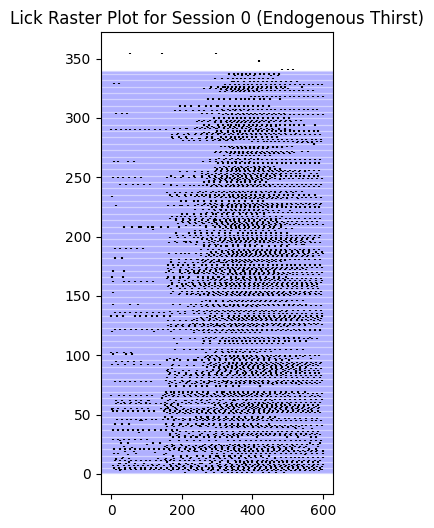

In [23]:
# let make lick raster plot for all trials in session 0
session_0_trials = behavior_df[behavior_df['session_id'] == 0]
fig, ax = plt.subplots(figsize=(3, 6))
for trial_idx, lick_times in enumerate(session_0_trials['lick_time']):
    lick_indices = np.where(lick_times == 1)[0]
    ax.vlines(lick_indices, trial_idx + 0.5, trial_idx + 1.5, color='black')
# shade thirsty and sated blocks
thirsty_indices = session_0_trials[session_0_trials['thirsty_sated_state'] == 'thirsty'].index
sated_indices = session_0_trials[session_0_trials['thirsty_sated_state'] == 'sated'].index
for idx in thirsty_indices:
    ax.axhspan(idx+.5 , idx + 1.5, color='blue', alpha=0.1)
ax.set_title('Lick Raster Plot for Session 0 (Endogenous Thirst)')
 

In [ ]:
#import slicetca
#import torch

import numpy as np
import pandas as pd
import pickle
import scipy.ndimage as spnd
import scipy.stats as sps
import matplotlib.pyplot as plt
import matplotlib

# first the neural data is in the shape of (neurons, timebin, trials) we want to convert it to (trials, neurons, time bins):
units_df = loaded_data[file_name_list[2]]['units_df']
neural_data = loaded_data[file_name_list[2]]['neural_data']
behavior_df = loaded_data[file_name_list[2]]['behavior_df']

neural_data = np.transpose(neural_data, (2, 0, 1))  # shape: (Ntrials, Nunits, timebin)
print(f'Neural data shape after transpose: {neural_data.shape} (trials, neurons, time bins)')  # should be (Ntrials, Nunits, timebin)
print(f'behavior data shape: {behavior_df.shape} (trials, features) ')

# smooth along time axis, using a Gaussian filter (sigma=2 with bin size 10 ms corresponds to 20 ms)
neural_data = spnd.gaussian_filter1d(neural_data, sigma=2, axis=-1)

# min-max scaling for each neuron for values between [0,1]
neural_data = np.array([d / d.max() for d in np.array([d - d.min() for d in neural_data])])

Neural data shape after transpose: (391, 452, 600) (trials, neurons, time bins)
behavior data shape: (391, 15) (trials, features) 


In [26]:
# let get some tiem steps 
odor_start_times_mean = behavior_df['odor_start_time'][behavior_df['odor_start_time'] != -1].mean()
odor_end_times_mean = behavior_df['odor_end_time'][behavior_df['odor_end_time'] != -1].mean()
reward_start_times_mean = behavior_df['reward_start_time'][behavior_df['reward_start_time'] != -1].mean()
reward_start_times_stad = behavior_df['reward_start_time'][behavior_df['reward_start_time'] != -1].std()

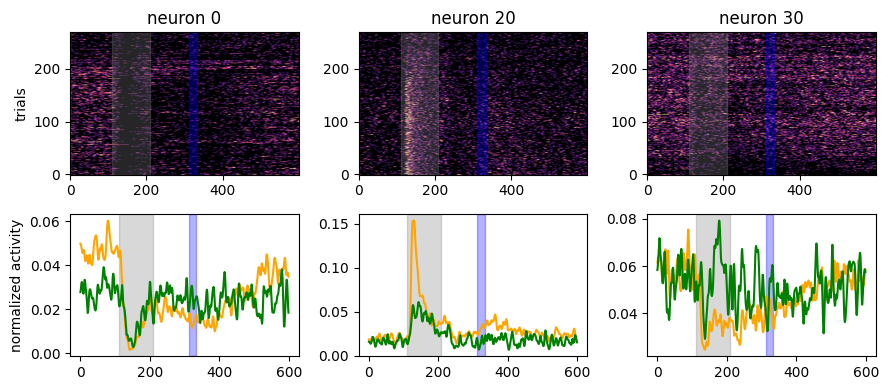

In [54]:
neurons = [0,20,30]

# index for sorting trials by go, no-go, and state

trial_idx = np.array(behavior_df['go_or_nogo'] == 'go')
states = ['thirsty', 'sated']
# colors represent thirsty and sated states
colors = {'thirsty': 'orange', 'sated': 'green'}

plt.figure(figsize=(9,4), dpi=100)
# heat maps sorted by target angle for three example neurons
for ni,n in enumerate(neurons):
    plt.subplot(2,3,ni+1)
    plt.imshow(neural_data[trial_idx][:,n], aspect='auto', vmin=0, vmax=.3, cmap='magma', origin='lower')
    # let add shaded area for odor and reward times
    y_lim = plt.ylim()
    plt.fill_betweenx(y_lim, odor_start_times_mean, odor_end_times_mean, color='gray', alpha=0.3, label='odor period' if ni==0 else "")
    plt.fill_betweenx(y_lim, reward_start_times_mean - reward_start_times_stad, reward_start_times_mean + reward_start_times_stad, color='blue', alpha=0.3, label='reward period' if ni==0 else "")
    plt.plot([0,0], [0,len(neural_data)], 'w--')
    plt.ylim(y_lim)
    if ni==0: plt.ylabel('trials')
    plt.title('neuron ' + str(n))

# condition-averaged, scaled & smoothed PSTHs
for ni,n in enumerate(neurons):
    plt.subplot(2,3,ni+4)
    for ai,a in enumerate(states):
        plt.plot(np.mean(neural_data[(behavior_df.thirsty_sated_state==a) & trial_idx][:,n], axis=0), '-', color=colors[a])
    # let add shaded area for odor and reward times
    y_lim = plt.ylim()
    plt.fill_betweenx(y_lim, odor_start_times_mean, odor_end_times_mean, color='gray', alpha=0.3, label='odor period' if ni==0 else "")
    plt.fill_betweenx(y_lim, reward_start_times_mean - reward_start_times_stad, reward_start_times_mean + reward_start_times_stad, color='blue', alpha=0.3, label='reward period' if ni==0 else "")
    plt.ylim(y_lim)    
    if ni==0: plt.ylabel('normalized activity')
plt.tight_layout()

In [ ]:
# determine kernel to run on ('cuda' when GPU is available, else 'cpu' which will be slower)
device = ('cuda' if torch.cuda.is_available() else 'cpu')

# transfer data to torch tensor
neural_data_tensor = torch.tensor(neural_data, device=device, dtype=torch.float32)

#The sliceTCA decomposition is going to be initialized with random weights between 0 and 1 (for non-negative sliceTCA).
#  Let's therefore rescale the data  so that initial weights have a similar magnitude as the data.
neural_data_tensor = neural_data_tensor/neural_data_tensor.std()


In [ ]:
train_mask, test_mask = slicetca.block_mask(dimensions=neural_data_tensor.shape,
                                            train_blocks_dimensions=(1, 1, 10), # Note that the blocks will be of size 2*train_blocks_dimensions + 1
                                            test_blocks_dimensions=(1, 1, 5), # Same, 2*test_blocks_dimensions + 1
                                            fraction_test=0.1,
                                            device=device)


# this will take a while to run as it fits 3*3*3*4 = 108 models
loss_grid, seed_grid = slicetca.grid_search(neural_data_tensor,
                                            min_ranks = [0, 0, 0],
                                            max_ranks = [4, 4, 4],
                                            sample_size=4,
                                            mask_train=train_mask,
                                            mask_test=test_mask,
                                            processes_grid=4,
                                            seed=1,
                                            min_std=10**-4,
                                            learning_rate=5*10**-3,
                                            max_iter=10**4,
                                            positive=True)

In [ ]:
slicetca.plot_grid(loss_grid, min_ranks=(3, 0, 0))